# RNN Backpropagation Through Time
## Q8: PyTorch Implementation + Visualisation

This notebook implements a **custom RNN cell** and runs a full forward + backward pass over **T=5 time steps**, and visualises:
- Hidden state norms across time
- Gradient norms per parameter
- Vanishing gradient decay across hidden states
- Weight matrix heatmaps (Wx, Wh)


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
ACCENT = ['#00d4ff','#ff6b6b','#ffd93d','#6bcb77','#c77dff']
print('Imports ready')


Imports ready


## 1. Custom RNN Cell & Model

Builds the RNN from scratch instead of using `nn.RNN`, so every parameter is visible for gradient inspection.

- **`CustomRNNCell`** — one time step: `h_t = tanh(x_t @ Wx.T + h_{t-1} @ Wh.T + b)`
  - `Wx` (8x4) maps input to hidden, `Wh` (8x8) maps previous hidden to hidden, `b` is bias.
  - Weights scaled by `0.1` so `Wh` starts small — this is what makes gradients vanish later.
- **`CustomRNN`** — loops the *same* cell over all `T` steps (weight sharing), collects each `h_t`, then feeds only the **last** hidden state to `self.fc` for the prediction.
  - `h.retain_grad()` keeps `dL/dh_t` for every step; without it PyTorch frees these non-leaf gradients and we could not plot the decay.
- Config: `T=5` steps, input 4-dim, hidden 8-dim, output 1 scalar, batch 1. Random input `x_seq`, target `1.0`.

In [2]:
class CustomRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wx = nn.Parameter(torch.randn(hidden_size, input_size)  * 0.1)
        self.Wh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.b  = nn.Parameter(torch.zeros(hidden_size))
    def forward(self, x_t, h_prev):
        return torch.tanh(x_t @ self.Wx.T + h_prev @ self.Wh.T + self.b)

class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = CustomRNNCell(input_size, hidden_size)
        self.fc   = nn.Linear(hidden_size, output_size)
    def forward(self, x_seq):
        T, batch, _ = x_seq.shape
        h = torch.zeros(batch, self.hidden_size)
        hidden_states = []
        for t in range(T):
            h = self.cell(x_seq[t], h)
            h.retain_grad()
            hidden_states.append(h)
        out = self.fc(hidden_states[-1])
        return out, hidden_states

T, input_size, hidden_size, output_size, batch = 5, 4, 8, 1, 1
x_seq  = torch.randn(T, batch, input_size)
target = torch.tensor([[1.0]])
model  = CustomRNN(input_size, hidden_size, output_size)
print(f'Total params: {sum(p.numel() for p in model.parameters())}')


Total params: 113


## 2. Forward Pass + BPTT

Runs one full training step and harvests every gradient.

- `model(x_seq)` unrolls 5 steps forward, `MSELoss` compares the scalar output to the target.
- `loss.backward()` triggers **BPTT**: the gradient flows back through the `fc` layer, then step-by-step from `h_5` to `h_1`, each hop multiplying by `Wh` and the `tanh` derivative.
- Collected here:
  - `h_norms` — how big each hidden state is (forward activations).
  - `grad_norms_h` — `||dL/dh_t||` per step (available thanks to `retain_grad`).
  - `param_grad_norms` — `||dL/dW||` for `Wx`, `Wh`, `b`, `fc.weight`, `fc.bias`.
- Expected in the printout: gradient norms shrink sharply from `h_5` back to `h_1` — the vanishing gradient.

In [3]:
output, hidden_states = model(x_seq)
loss = nn.MSELoss()(output, target)
loss.backward()

h_norms      = [h.detach().norm().item() for h in hidden_states]
grad_norms_h = [h.grad.norm().item() if h.grad is not None else 0.0 for h in hidden_states]
param_info   = {'Wx': model.cell.Wx, 'Wh': model.cell.Wh,
                'b':  model.cell.b,  'fc.weight': model.fc.weight, 'fc.bias': model.fc.bias}
param_grad_norms = {k: v.grad.norm().item() for k, v in param_info.items()}

print(f'Loss   : {loss.item():.6f}')
print(f'Output : {output.item():.6f}  |  Target : {target.item():.6f}')
print()
print('Hidden norms :', [f'{n:.4f}' for n in h_norms])
print('Grad   norms :', [f'{n:.6f}' for n in grad_norms_h])
print()
for k, v in param_grad_norms.items():
    print(f'  dL/d{k:<12} = {v:.6f}')


Loss   : 0.804259
Output : 0.103195  |  Target : 1.000000

Hidden norms : ['0.8028', '0.6780', '0.2710', '0.3148', '0.4014']
Grad   norms : ['0.002996', '0.015983', '0.069966', '0.320255', '1.138902']

  dL/dWx           = 1.337316
  dL/dWh           = 0.369596
  dL/db            = 1.102910
  dL/dfc.weight    = 0.719995
  dL/dfc.bias      = 1.793610


## 3. Hidden State Norms & Vanishing Gradient

Two side-by-side plots contrasting the forward and backward signal.

- **Left (bars)** — `||h_t||` per step. Stays in a stable range because `tanh` saturates values into `[-1, 1]`, so activations do not blow up.
- **Right (line)** — `||dL/dh_t||` per step. Decays going *backwards* in time: `h_5` (closest to the loss) has the largest gradient, `h_1` the smallest.
- Takeaway: forward pass is healthy while the backward signal dies out, so early time steps receive almost no learning signal — the core reason plain RNNs struggle with long dependencies (and why LSTM/GRU exist).

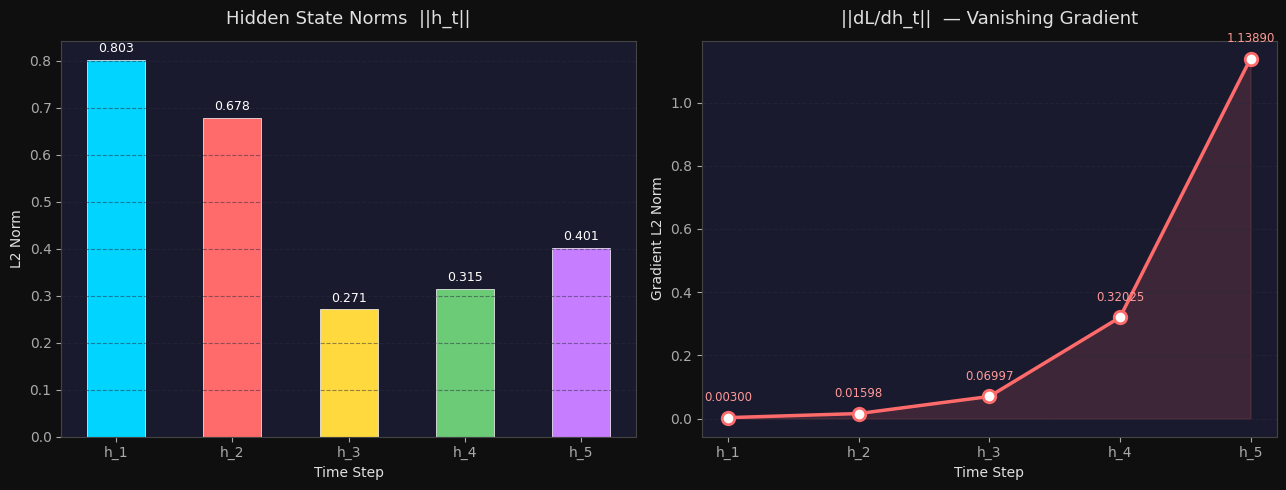

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f0f')
steps = [f'h_{i+1}' for i in range(T)]

ax = axes[0]
bars = ax.bar(steps, h_norms, color=ACCENT[:T], edgecolor='white', linewidth=0.5, width=0.5)
ax.set_title('Hidden State Norms  ||h_t||', fontsize=13, pad=12)
ax.set_xlabel('Time Step'); ax.set_ylabel('L2 Norm'); ax.grid(axis='y')
for bar, val in zip(bars, h_norms):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='white')

ax = axes[1]
ax.plot(steps, grad_norms_h, 'o-', color='#ff6b6b', linewidth=2.5,
        markersize=9, markerfacecolor='white', markeredgecolor='#ff6b6b', markeredgewidth=2)
ax.fill_between(range(T), grad_norms_h, alpha=0.15, color='#ff6b6b')
ax.set_title('||dL/dh_t||  — Vanishing Gradient', fontsize=13, pad=12)
ax.set_xlabel('Time Step'); ax.set_ylabel('Gradient L2 Norm')
ax.set_xticks(range(T)); ax.set_xticklabels(steps); ax.grid(axis='y')
for i, (s, v) in enumerate(zip(steps, grad_norms_h)):
    ax.annotate(f'{v:.5f}', xy=(i, v), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=8.5, color='#ff9999')

plt.tight_layout(); plt.show()


## 4. Parameter Gradient Norms

Horizontal bar chart of `||dL/dW||` for each learnable tensor.

- Compares how strong the update signal is across `Wx`, `Wh`, `b`, `fc.weight`, `fc.bias`.
- `fc.*` sits closest to the loss so it usually gets the largest gradient; the recurrent `Wx` / `Wh` gradients are sums over all 5 time steps but are damped by the vanishing effect.
- These are exactly the values an optimizer such as SGD or Adam would consume, so small bars mean slow learning for that parameter.

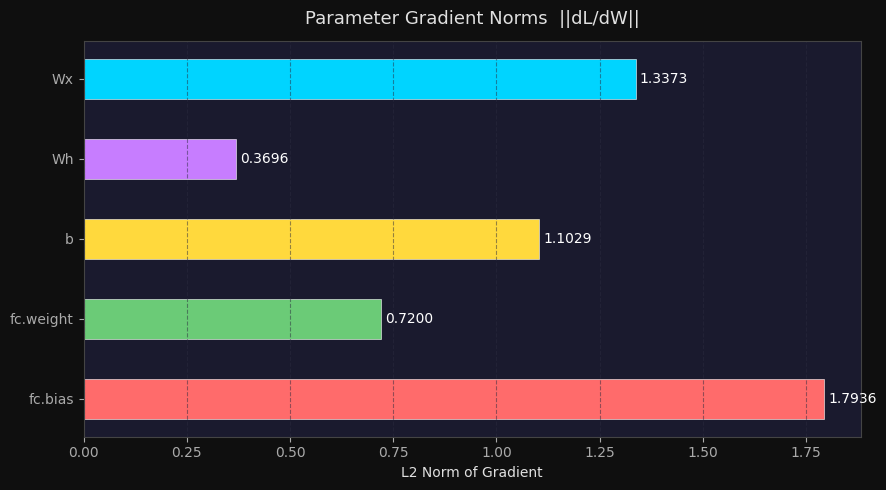

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f0f0f')
names  = list(param_grad_norms.keys())
norms  = list(param_grad_norms.values())
colors = ['#00d4ff','#c77dff','#ffd93d','#6bcb77','#ff6b6b']
bars = ax.barh(names, norms, color=colors, edgecolor='white', linewidth=0.4, height=0.5)
ax.set_title('Parameter Gradient Norms  ||dL/dW||', fontsize=13, pad=12)
ax.set_xlabel('L2 Norm of Gradient'); ax.grid(axis='x'); ax.invert_yaxis()
for bar, val in zip(bars, norms):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, color='white')
plt.tight_layout(); plt.show()


## 5. Weight Gradient Heatmaps

Element-wise view of the recurrent gradients instead of a single norm.

- **Left** — `dL/dWx` (8x4): sensitivity of the loss to each input-to-hidden connection.
- **Right** — `dL/dWh` (8x8): sensitivity to each hidden-to-hidden connection; this matrix is applied at every time step, so it accumulates contributions from all 5 steps.
- `cmap='coolwarm'` with `center=0`: red = positive gradient, blue = negative, near-white = ~zero (that weight barely affects the loss).
- Pattern to look for: mostly pale cells means the gradient signal is weak and spread thin.

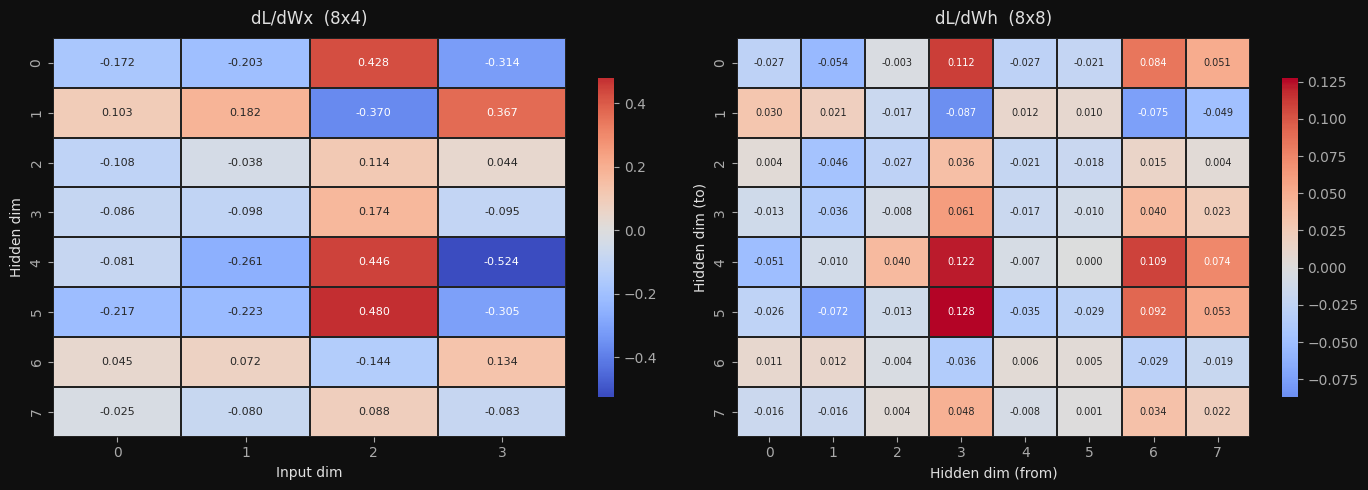

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')
wx_grad = model.cell.Wx.grad.detach().numpy()
wh_grad = model.cell.Wh.grad.detach().numpy()

sns.heatmap(wx_grad, ax=axes[0], cmap='coolwarm', center=0,
            annot=True, fmt='.3f', annot_kws={'size': 8},
            linewidths=0.3, linecolor='#222', cbar_kws={'shrink': 0.8})
axes[0].set_title('dL/dWx  (8x4)', fontsize=12, pad=10)
axes[0].set_xlabel('Input dim'); axes[0].set_ylabel('Hidden dim')

sns.heatmap(wh_grad, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.3f', annot_kws={'size': 7},
            linewidths=0.3, linecolor='#222', cbar_kws={'shrink': 0.8})
axes[1].set_title('dL/dWh  (8x8)', fontsize=12, pad=10)
axes[1].set_xlabel('Hidden dim (from)'); axes[1].set_ylabel('Hidden dim (to)')

plt.tight_layout(); plt.show()


## 6. BPTT Gradient Flow Diagram

Schematic summary of the whole computation, annotated with the real numbers from section 2.

- Circles `h1..h5` are the hidden states; node opacity scales with time step, so later steps look brighter.
- **Grey arrows (top)** — forward pass, `h_t` feeding `h_{t+1}`.
- **Yellow arrow** — the loss `L`, attached only to the final hidden state.
- **Red arrows (bottom, right to left)** — BPTT, gradient travelling backwards in time.
- The number under each node is the actual `||dL/dh_t||`, so the shrink from `h5` to `h1` is visible as concrete values rather than just a shape.

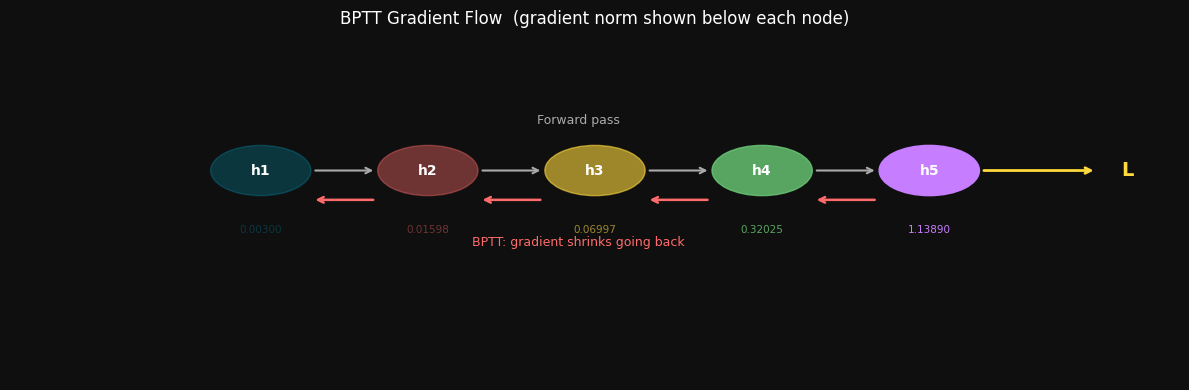

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')
ax.set_xlim(-0.5, 6.5); ax.set_ylim(-1, 3); ax.axis('off')

node_y = 1.5
xs = [1, 2, 3, 4, 5]
labels = ['h1', 'h2', 'h3', 'h4', 'h5']
grad_display = [f'{v:.5f}' for v in grad_norms_h]

for i, (x, lbl, gd) in enumerate(zip(xs, labels, grad_display)):
    alpha = 0.2 + 0.8 * (i / (T - 1))
    circle = plt.Circle((x, node_y), 0.3, color=ACCENT[i], alpha=alpha, zorder=3)
    ax.add_patch(circle)
    ax.text(x, node_y, lbl, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', zorder=4)
    ax.text(x, node_y - 0.65, gd, ha='center', va='top',
            fontsize=7.5, color=ACCENT[i], alpha=alpha)

for i in range(T - 1):
    ax.annotate('', xy=(xs[i+1]-0.31, node_y),
                xytext=(xs[i]+0.31, node_y),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))
ax.text(2.9, node_y+0.55, 'Forward pass', color='#aaa', fontsize=9, ha='center')

for i in range(T-1, 0, -1):
    ax.annotate('', xy=(xs[i-1]+0.31, node_y-0.35),
                xytext=(xs[i]-0.31, node_y-0.35),
                arrowprops=dict(arrowstyle='->', color='#ff6b6b', lw=1.8))
ax.text(2.9, node_y-0.9, 'BPTT: gradient shrinks going back',
        color='#ff6b6b', fontsize=9, ha='center')

ax.annotate('', xy=(xs[-1]+0.31, node_y),
            xytext=(6.0, node_y),
            arrowprops=dict(arrowstyle='<-', color='#ffd93d', lw=2))
ax.text(6.15, node_y, 'L', ha='left', va='center', fontsize=14,
        color='#ffd93d', fontweight='bold')

ax.set_title('BPTT Gradient Flow  (gradient norm shown below each node)',
             fontsize=12, color='white', pad=15)
plt.tight_layout(); plt.show()
